In [2]:
import sys
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, log_loss

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

save_dir = "Images/Model_Performance/"
os.makedirs(save_dir, exist_ok=True)

from src.ETL.Transform.feature_engineering import preprocessing

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


In [3]:
import sys
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, log_loss

# Add project root to sys.path to import local modules
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.ETL.Transform.feature_engineering import preprocessing

# Configure visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [4]:
messy_dataset = pd.read_csv('../Data/raw/nations_data.csv')
dataset, team_stats, team_elos = preprocessing(messy_dataset)

X = dataset.drop(columns=['Home Team', 'Away Team', 'Final Result'])
y = dataset['Final Result']

labels = {'A': 0, 'D': 1, 'H': 2}
y = y.map(labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Dataset features shape: {X.shape}")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Dataset features shape: (806, 26)
Training set shape: (644, 26)
Test set shape: (162, 26)


In [5]:
dumped_dir = '../src/Models/Dumped_models'

CT = joblib.load(f'{dumped_dir}/ColumnTransformer.pkl')
imputer = joblib.load(f'{dumped_dir}/SimpleImputer.pkl')
scaler = joblib.load(f'{dumped_dir}/StandardScaler.pkl')

rf_model = joblib.load(f'{dumped_dir}/RandomForest_Classifier.pkl')
xgb_model = joblib.load(f'{dumped_dir}/XGBoost_Classifier.pkl')
lr_model = joblib.load(f'{dumped_dir}/LogisticRegressor.pkl')
ann_model = joblib.load(f'{dumped_dir}/Neural_Network.pkl')

In [6]:
X_test_trans = CT.transform(X_test)
X_test_imputed = imputer.transform(X_test_trans)
X_test_scaled = scaler.transform(X_test_imputed)

predictions = {}
probabilities = {}

predictions['Random Forest'] = rf_model.predict(X_test_imputed)
probabilities['Random Forest'] = rf_model.predict_proba(X_test_imputed)

predictions['XGBoost Calibrated'] = xgb_model.predict(X_test_imputed)
probabilities['XGBoost Calibrated'] = xgb_model.predict_proba(X_test_imputed)

predictions['Logistic Regression'] = lr_model.predict(X_test_scaled)
probabilities['Logistic Regression'] = lr_model.predict_proba(X_test_scaled)

ann_probs = ann_model.predict_proba(X_test_scaled)
predictions['Neural Network'] = np.argmax(ann_probs, axis=1)
probabilities['Neural Network'] = ann_probs

target_names = ['Away Win (A)', 'Draw (D)', 'Home Win (H)']

for model_name in predictions.keys():
    print("=" * 60)
    print(f" Model: {model_name}")
    print("=" * 60)
    print(classification_report(y_test, predictions[model_name], target_names=target_names))
    print(f"Accuracy: {accuracy_score(y_test, predictions[model_name]):.4%}")
    print(f"Log Loss: {log_loss(y_test, probabilities[model_name]):.4f}\n")

 Model: Random Forest
              precision    recall  f1-score   support

Away Win (A)       0.67      0.65      0.66        48
    Draw (D)       0.00      0.00      0.00        31
Home Win (H)       0.66      0.90      0.76        83

    accuracy                           0.65       162
   macro avg       0.44      0.52      0.47       162
weighted avg       0.54      0.65      0.59       162

Accuracy: 65.4321%
Log Loss: 0.8837

 Model: XGBoost Calibrated
              precision    recall  f1-score   support

Away Win (A)       0.65      0.67      0.66        48
    Draw (D)       0.00      0.00      0.00        31
Home Win (H)       0.65      0.89      0.76        83

    accuracy                           0.65       162
   macro avg       0.44      0.52      0.47       162
weighted avg       0.53      0.65      0.58       162

Accuracy: 65.4321%
Log Loss: 0.8743

 Model: Logistic Regression
              precision    recall  f1-score   support

Away Win (A)       0.69      0.6

c:\Users\stepa\OneDrive\Έγγραφα\World_Cup_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\stepa\OneDrive\Έγγραφα\World_Cup_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\stepa\OneDrive\Έγγραφα\World_Cup_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

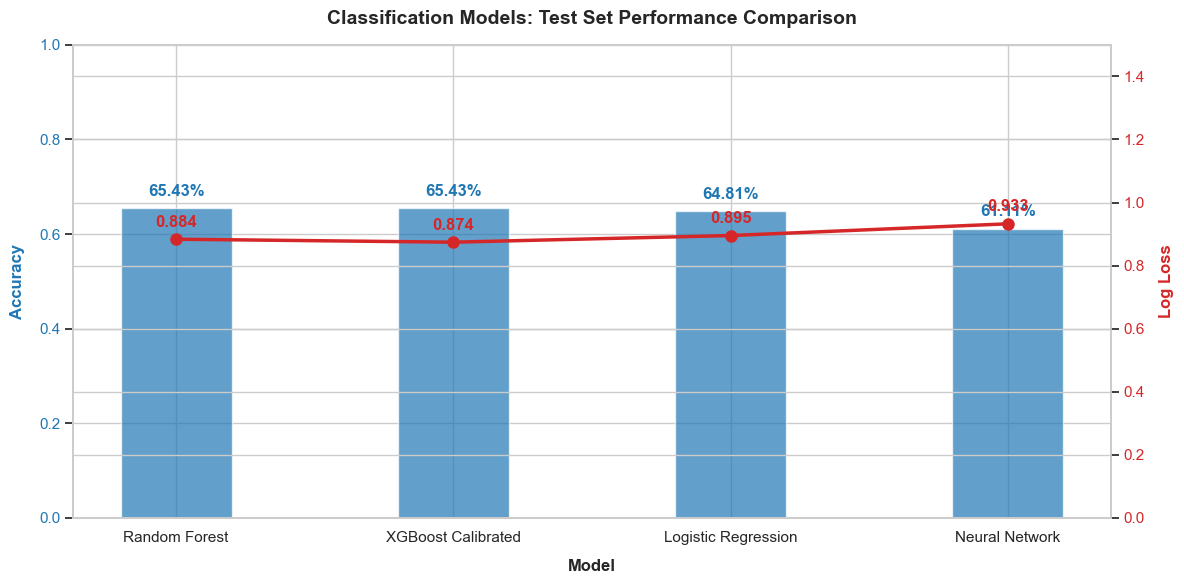

In [7]:
model_names = list(predictions.keys())
accuracies = [accuracy_score(y_test, predictions[m]) for m in model_names]
losses = [log_loss(y_test, probabilities[m]) for m in model_names]

fig, ax1 = plt.subplots(figsize=(12, 6))

color = '#1f77b4'
ax1.set_xlabel('Model', fontweight='bold', labelpad=10)
ax1.set_ylabel('Accuracy', color=color, fontweight='bold', labelpad=10)
bars = ax1.bar(model_names, accuracies, color=color, alpha=0.7, width=0.4, label='Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 1.0)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.2%}',
             ha='center', va='bottom', color=color, fontweight='bold')

ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('Log Loss', color=color, fontweight='bold', labelpad=10)
line = ax2.plot(model_names, losses, color=color, marker='o', linewidth=2.5, markersize=8, label='Log Loss')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 1.5)
for i, val in enumerate(losses):
    ax2.annotate(f'{val:.3f}', (model_names[i], losses[i] + 0.04),
                 color=color, fontweight='bold', ha='center')

plt.title('Classification Models: Test Set Performance Comparison', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.savefig('Images/Model_Metrics/test_set_performance.png')
plt.show()

In [8]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

tscv = TimeSeriesSplit(n_splits=5)
inner_cv = TimeSeriesSplit(n_splits=3) 

categorical_features = ['tournament_name']

cv_scores = {
    'Random Forest': [],
    'XGBoost Calibrated': [],
    'Logistic Regression': [],
    'Neural Network': []
}

for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    
    X_tr, X_te = X.iloc[train_index], X.iloc[test_index]
    y_tr, y_te = y.iloc[train_index], y.iloc[test_index]
    
    ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(handle_unknown='ignore'), categorical_features)], remainder='passthrough')
    X_tr_trans = ct.fit_transform(X_tr)
    X_te_trans = ct.transform(X_te)
    
    imputer_fold = SimpleImputer(strategy='median')
    X_tr_imp = imputer_fold.fit_transform(X_tr_trans)
    X_te_imp = imputer_fold.transform(X_te_trans)
    
    scaler_fold = StandardScaler()
    X_tr_scaled = scaler_fold.fit_transform(X_tr_imp)
    X_te_scaled = scaler_fold.transform(X_te_imp)
    
    rf_grid = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid={
        "n_estimators": [40,55,60],
        "max_depth": [5,8,12],
        "criterion": ["gini"],
        "min_samples_split": [2, 5, 10]
    },
        cv=inner_cv, 
        n_jobs=-1, 
        scoring='neg_log_loss'
    )
    rf_grid.fit(X_tr_imp, y_tr)
    rf = rf_grid.best_estimator_
    
    xgb_grid = GridSearchCV(
        estimator=XGBClassifier(random_state=42, eval_metric='mlogloss'),
        param_grid={
        'n_estimators':[42,67,80],
        'max_depth':[3,5,6],
        'learning_rate':[0.08,0.1,0.15,0.22]
    },
        cv=inner_cv, 
        n_jobs=-1, 
        scoring='neg_log_loss'
    )
    xgb_grid.fit(X_tr_imp, y_tr)
    
    xgb = CalibratedClassifierCV(estimator=xgb_grid.best_estimator_, method='sigmoid')
    xgb.fit(X_tr_imp, y_tr)
    
    lr_grid = GridSearchCV(
        estimator=LogisticRegression(max_iter=1900, random_state=42),
        param_grid={
            'C': [0.01, 0.1, 1],
            'solver': ['lbfgs', 'saga'],
            'class_weight': [None, 'balanced']
        },
        cv=inner_cv, 
        n_jobs=5, 
        scoring='neg_log_loss'
    )
    lr_grid.fit(X_tr_scaled, y_tr)
    lr = lr_grid.best_estimator_
    
    ann_grid = GridSearchCV(
        estimator=MLPClassifier(early_stopping=True, validation_fraction=0.2, max_iter=1500, random_state=42),
        param_grid={
        'hidden_layer_sizes': [(128,64),(64,32)],
        'alpha': [1e-5, 0.001],
        'activation': ['relu'],
        'learning_rate': ['constant', 'adaptive'],
        'learning_rate_init': [0.001]
    },
        cv=inner_cv, 
        n_jobs=-1, 
        scoring='neg_log_loss'
    )
    ann_grid.fit(X_tr_scaled, y_tr)
    ann = ann_grid.best_estimator_
    
    rf_acc = accuracy_score(y_te, rf.predict(X_te_imp))
    xgb_acc = accuracy_score(y_te, xgb.predict(X_te_imp))
    lr_acc = accuracy_score(y_te, lr.predict(X_te_scaled))
    ann_acc = accuracy_score(y_te, ann.predict(X_te_scaled))
    
    cv_scores['Random Forest'].append(rf_acc)
    cv_scores['XGBoost Calibrated'].append(xgb_acc)
    cv_scores['Logistic Regression'].append(lr_acc)
    cv_scores['Neural Network'].append(ann_acc)
    
    print(f"Fold {fold + 1} Accuracy - RF: {rf_acc:.2%}, XGB: {xgb_acc:.2%}, LR: {lr_acc:.2%}, ANN: {ann_acc:.2%}\n")

Fold 1 Accuracy - RF: 47.76%, XGB: 50.75%, LR: 47.01%, ANN: 46.27%

Fold 2 Accuracy - RF: 54.48%, XGB: 52.99%, LR: 50.75%, ANN: 54.48%

Fold 3 Accuracy - RF: 61.19%, XGB: 63.43%, LR: 61.19%, ANN: 52.99%

Fold 4 Accuracy - RF: 63.43%, XGB: 61.94%, LR: 66.42%, ANN: 64.18%

Fold 5 Accuracy - RF: 62.69%, XGB: 61.94%, LR: 61.94%, ANN: 59.70%



,Random Forest,XGBoost Calibrated,Logistic Regression,Neural Network
Fold 1,47.76%,50.75%,47.01%,46.27%
Fold 2,54.48%,52.99%,50.75%,54.48%
Fold 3,61.19%,63.43%,61.19%,52.99%
Fold 4,63.43%,61.94%,66.42%,64.18%
Fold 5,62.69%,61.94%,61.94%,59.70%
Mean Accuracy,57.91%,58.21%,57.46%,55.52%
Std Dev,6.69%,5.88%,8.19%,6.81%


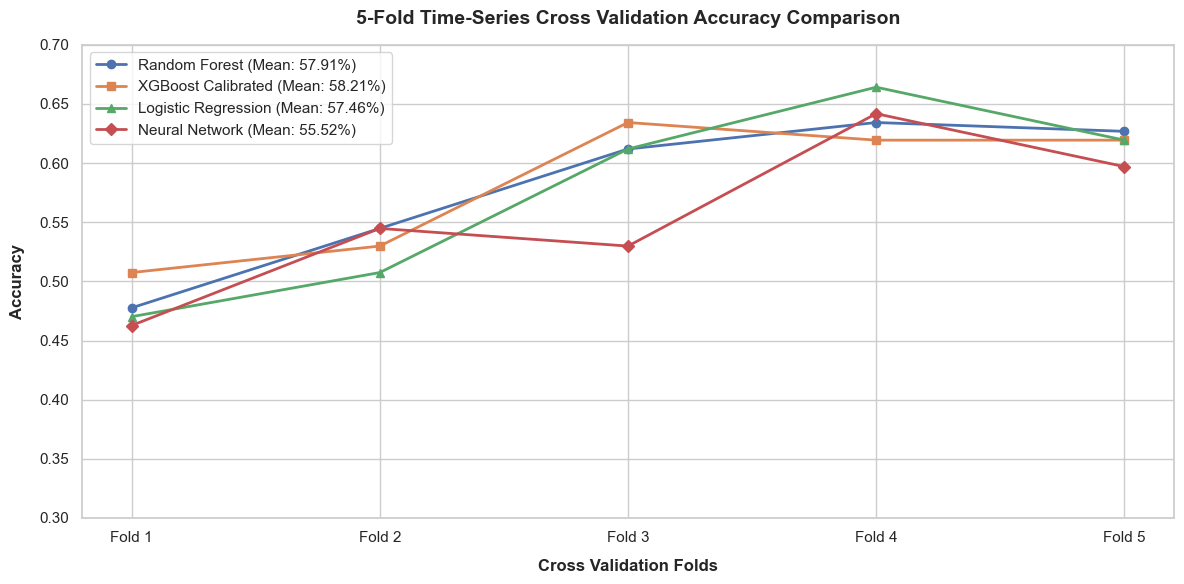

In [9]:
cv_df = pd.DataFrame(cv_scores)
cv_df.index = [f'Fold {i+1}' for i in range(5)]

summary_df = cv_df.copy()
summary_df.loc['Mean Accuracy'] = cv_df.mean()
summary_df.loc['Std Dev'] = cv_df.std()

display(summary_df.style.format("{:.2%}").background_gradient(cmap='Blues', axis=0))

plt.figure(figsize=(12, 6))
markers = ['o', 's', '^', 'D']
for i, model in enumerate(cv_df.columns):
    plt.plot(cv_df.index, cv_df[model], marker=markers[i], linewidth=2, label=f"{model} (Mean: {cv_df[model].mean():.2%})")

plt.title('5-Fold Time-Series Cross Validation Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cross Validation Folds', fontweight='bold', labelpad=10)
plt.ylabel('Accuracy', fontweight='bold', labelpad=10)
plt.ylim(0.3, 0.7)
plt.legend(loc='best')
plt.tight_layout()
dir='Images/Model_Metrics/'
os.makedirs(dir,exist_ok=True)
plt.savefig('Images/Model_Metrics/cross_val_score_of_plot.png')
plt.show()